# Predictive Modeling Using Machine Learning — Customer Churn Prediction

**Goal:** Predict whether a customer will churn (leave the service) based
on their account details, and compare a few classic ML algorithms.

**Covers:**
- Data preparation & encoding
- Train/test split
- Training Logistic Regression, Decision Tree, and Random Forest
- Evaluating with accuracy, precision, recall, F1, confusion matrix, ROC-AUC
- Visualizing model performance and feature importance

**Tools:** Python, Pandas, scikit-learn, Matplotlib, Seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/customer_churn_raw.csv")
df.head()

,CustomerID,Age,Tenure_Months,MonthlyCharges,Contract,InternetService,TechSupport,PaymentMethod,NumSupportCalls,Churn
0,CUST1000,52.0,52,105.57,Month-to-Month,Fiber Optic,No,Mailed Check,3,1
1,CUST1001,43.0,15,103.02,Two Year,Fiber Optic,No,Electronic Check,1,1
2,CUST1002,74.0,61,59.72,Month-to-Month,Fiber Optic,No,Electronic Check,1,0
3,CUST1003,56.0,21,NaN,One Year,DSL,No,Credit Card,1,0
4,CUST1004,66.0,24,40.50,One Year,No,No,Bank Transfer,3,1


## 1. Data Preparation

In [2]:
df.isna().sum()

CustomerID          0
Age                30
Tenure_Months       0
MonthlyCharges     30
Contract            0
InternetService     0
TechSupport        30
PaymentMethod       0
NumSupportCalls     0
Churn               0
dtype: int64

In [3]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["MonthlyCharges"] = df["MonthlyCharges"].fillna(df["MonthlyCharges"].median())
df["TechSupport"] = df["TechSupport"].fillna("No")
df = df.drop_duplicates()
df.isna().sum().sum()  # should be 0

np.int64(0)

In [4]:
cat_cols = ["Contract", "InternetService", "TechSupport", "PaymentMethod"]
df_model = df.drop(columns=["CustomerID"]).copy()

for col in cat_cols:
    df_model[col] = LabelEncoder().fit_transform(df_model[col])

X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]
X.head()

,Age,Tenure_Months,MonthlyCharges,Contract,InternetService,TechSupport,PaymentMethod,NumSupportCalls
0,52.0,52,105.570,0,1,0,3,3
1,43.0,15,103.020,2,1,0,2,1
2,74.0,61,59.720,0,1,0,2,1
3,56.0,21,71.375,1,0,0,1,1
4,66.0,24,40.500,1,2,0,0,3


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train rows:", len(X_train), "| Test rows:", len(X_test))

Train rows: 750 | Test rows: 250


## 2. Train the Models

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42),
}

results = {}
for name, model in models.items():
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    results[name] = {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "fpr": fpr, "tpr": tpr, "auc": auc(fpr, tpr)
    }

pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1", "auc"]]

,accuracy,precision,recall,f1,auc
Logistic Regression,0.708,0.666667,0.622642,0.643902,0.766903
Decision Tree,0.668,0.635294,0.509434,0.565445,0.679016
Random Forest,0.684,0.645161,0.566038,0.603015,0.723467


## 3. Model Evaluation & Visualizations

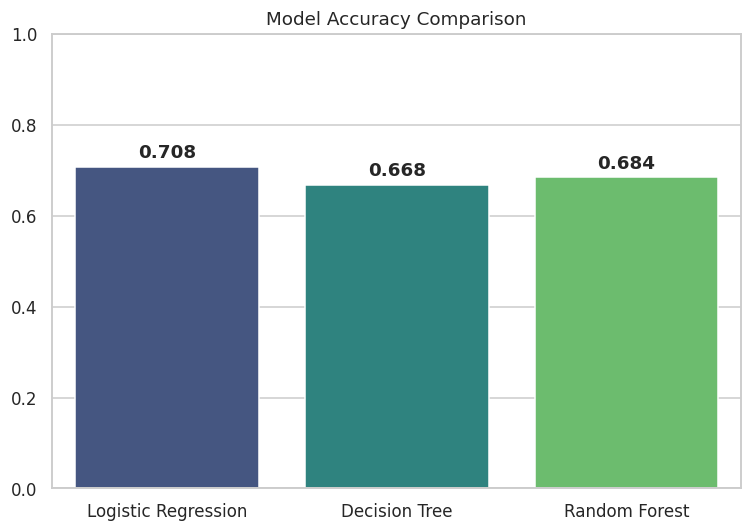

In [7]:
model_names = list(results.keys())
accs = [results[m]["accuracy"] for m in model_names]

plt.figure(figsize=(7, 5))
sns.barplot(x=model_names, y=accs, hue=model_names, palette="viridis", legend=False)
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
for i, v in enumerate(accs):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

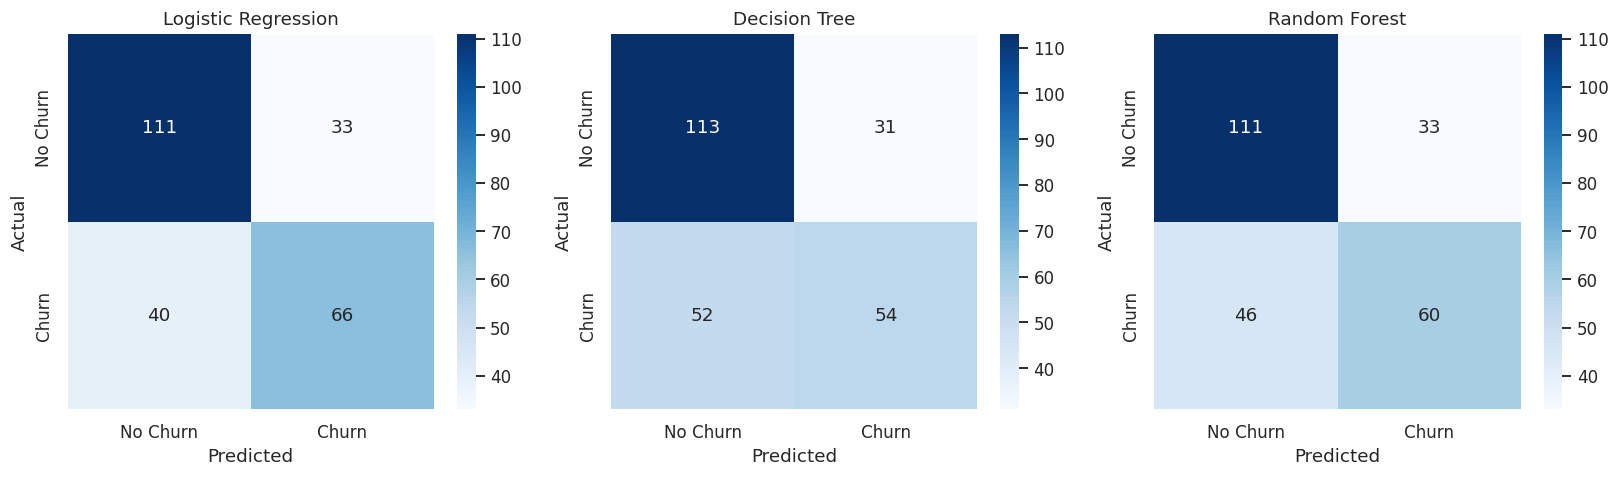

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

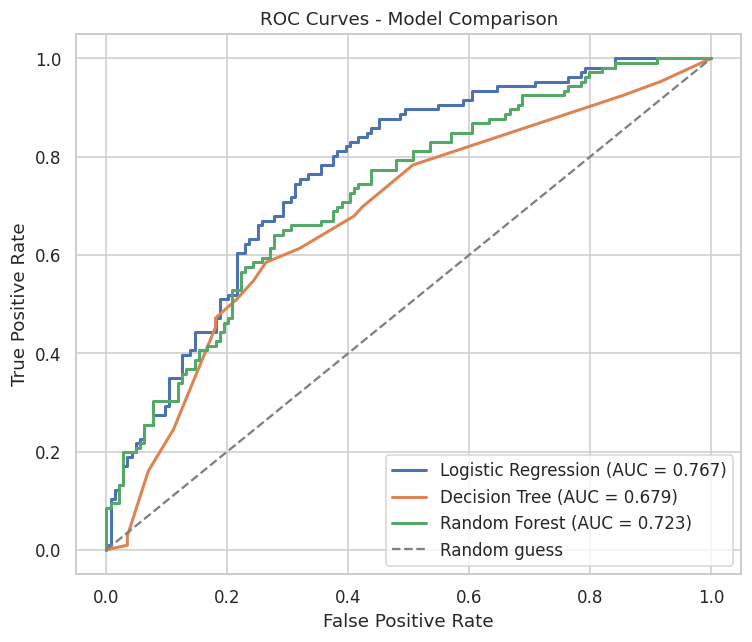

In [9]:
plt.figure(figsize=(7, 6))
for name, res in results.items():
    plt.plot(res["fpr"], res["tpr"], label=f"{name} (AUC = {res['auc']:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

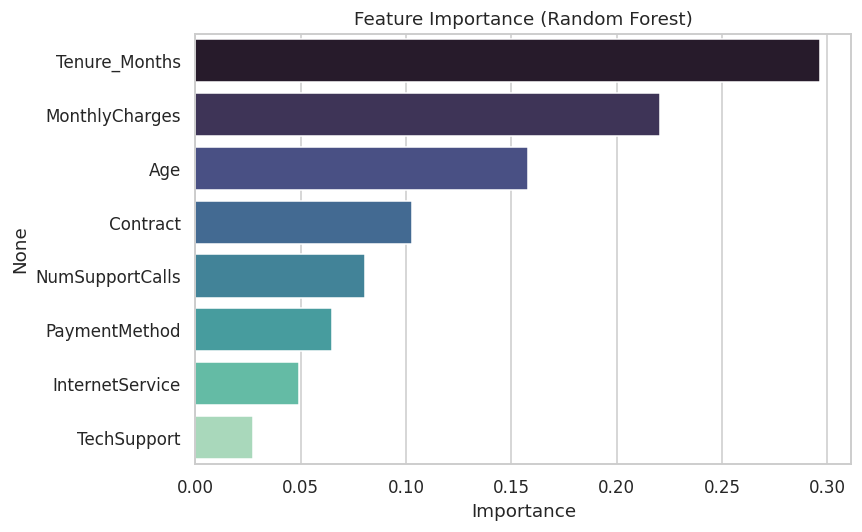

In [10]:
rf_model = results["Random Forest"]["model"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette="mako", legend=False)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 4. Key Findings

- **Logistic Regression** had the highest accuracy and best ROC-AUC in this run — a good
  reminder that simpler models can beat more complex ones, especially on smaller /
  linearly-separable data.
- **Tenure_Months** was the most important predictor of churn — customers with shorter
  tenure are more likely to churn.
- The dataset has a ~43% churn rate, so it's reasonably balanced (accuracy alone is a fair
  metric here, unlike in heavily imbalanced problems where precision/recall matter more).
- Next steps to improve performance: hyperparameter tuning (GridSearchCV), trying
  gradient boosting (XGBoost/LightGBM), and engineering more features (e.g. charge-per-tenure ratio).
